=== 仮説1の検証結果 ===
vehicle_type=1
morning=7-9 / evening=17-19
対象区間数: 960
夕>朝 の区間数: 138
夕>朝 の割合: 0.144


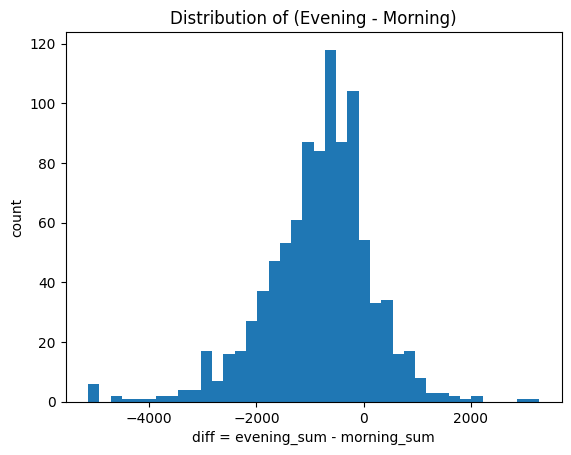

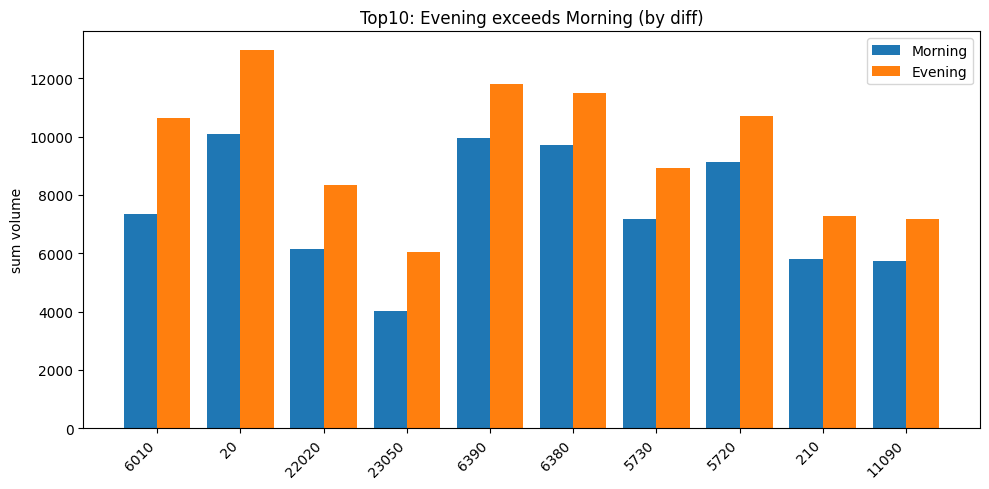


=== 夕が強いTopN（diff大） ===
 unit_section_no  morning_sum  evening_sum  diff  evening_over_morning  route_name start_name  end_name
            6010         7344        10622  3278              1.446351     高速中央環状線  葛飾区・江戸川区境  高速７号小松川線
              20        10079        12962  2883              1.286040 中央自動車道富士吉田線      新宿国立線 杉並区・世田谷区境
           22020         6129         8332  2203              1.359439    一般国道２４６号   千代田区・港区境     環状三号線
           23050         4002         6028  2026              1.506247    一般国道２５４号   板橋区・練馬区境     環状八号線
            6390         9947        11805  1858              1.186790                                 
            6380         9705        11506  1801              1.185574                                 
            5730         7161         8932  1771              1.247312     高速６号三郷線   葛飾区・足立区境  王子金町江戸川線
            5720         9138        10703  1565              1.171263     高速６号三郷線    高速中央環状線  葛飾区・足立区境
             210         5795         7

In [1]:
# 仮説1（Jupyter用・1セルで完結）
# 仮説：東京の区間では「夕方(17-19時台)の交通量合計 > 朝(7-9時台)の交通量合計」の区間が多い

import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= パラメータ（ここだけ変えればOK） =========
DB_PATH = Path("traffic.db")   # notebookと同じ階層ならこれでOK。違うならパスを書き換え
VEHICLE_TYPE = "1"             # 車種区分（例："1"）。DBの値に合わせて変更
H_MORNING = (7, 9)             # 朝
H_EVENING = (17, 19)           # 夕
TOPN = 10

# ========= DB→集計（必ずクエリで取得） =========
con = sqlite3.connect(DB_PATH)

sql = """
WITH base AS (
  SELECT unit_section_no, vehicle_type, hour, COALESCE(volume,0) AS volume
  FROM traffic_hourly
  WHERE vehicle_type = ?
),
agg AS (
  SELECT
    unit_section_no,
    SUM(CASE WHEN hour BETWEEN ? AND ? THEN volume ELSE 0 END) AS morning_sum,
    SUM(CASE WHEN hour BETWEEN ? AND ? THEN volume ELSE 0 END) AS evening_sum
  FROM base
  GROUP BY unit_section_no
)
SELECT
  a.unit_section_no,
  a.morning_sum,
  a.evening_sum,
  (a.evening_sum - a.morning_sum) AS diff,
  CASE WHEN a.morning_sum = 0 THEN NULL ELSE 1.0 * a.evening_sum / a.morning_sum END AS evening_over_morning,
  COALESCE(NULLIF(s.route_name,''),'') AS route_name,
  COALESCE(NULLIF(s.start_name,''),'') AS start_name,
  COALESCE(NULLIF(s.end_name,''),'') AS end_name
FROM agg a
LEFT JOIN segments s ON s.unit_section_no = a.unit_section_no
ORDER BY a.unit_section_no;
"""

df = pd.read_sql_query(
    sql, con,
    params=[VEHICLE_TYPE, H_MORNING[0], H_MORNING[1], H_EVENING[0], H_EVENING[1]]
)

# ========= 仮説判定 =========
valid = df[(df["morning_sum"] > 0) | (df["evening_sum"] > 0)].copy()
valid["evening_gt_morning"] = valid["evening_sum"] > valid["morning_sum"]

n = len(valid)
count_true = int(valid["evening_gt_morning"].sum())
ratio = count_true / n if n else np.nan

print("=== 仮説1の検証結果 ===")
print(f"vehicle_type={VEHICLE_TYPE}")
print(f"morning={H_MORNING[0]}-{H_MORNING[1]} / evening={H_EVENING[0]}-{H_EVENING[1]}")
print(f"対象区間数: {n}")
print(f"夕>朝 の区間数: {count_true}")
print(f"夕>朝 の割合: {ratio:.3f}")

# ========= 可視化1：diff分布 =========
plt.figure()
plt.hist(valid["diff"], bins=40)
plt.xlabel("diff = evening_sum - morning_sum")
plt.ylabel("count")
plt.title("Distribution of (Evening - Morning)")
plt.show()

# ========= 可視化2：夕が強いTopN（朝vs夕） =========
top_evening = valid.sort_values("diff", ascending=False).head(TOPN).copy()

plt.figure(figsize=(10, 5))
x = np.arange(len(top_evening))
plt.bar(x - 0.2, top_evening["morning_sum"], width=0.4, label="Morning")
plt.bar(x + 0.2, top_evening["evening_sum"], width=0.4, label="Evening")
plt.xticks(x, top_evening["unit_section_no"].astype(str), rotation=45, ha="right")
plt.ylabel("sum volume")
plt.title(f"Top{TOPN}: Evening exceeds Morning (by diff)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== 夕が強いTopN（diff大） ===")
display_cols = ["unit_section_no","morning_sum","evening_sum","diff","evening_over_morning","route_name","start_name","end_name"]
print(top_evening[display_cols].to_string(index=False))

# ========= 保存（レポート用） =========
out_path = Path(f"hyp1_vehicle{VEHICLE_TYPE}_m{H_MORNING[0]}-{H_MORNING[1]}_e{H_EVENING[0]}-{H_EVENING[1]}.csv")
valid.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"\nCSV保存: {out_path.resolve()}")

con.close()
